In [10]:
import os

os.makedirs("../outputs", exist_ok=True)

print("Outputs folder ready")

Outputs folder ready


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/nav_history_clean.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
scheme_perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


# Task 1: VaR & CVaR

In [12]:
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

risk_metrics = []

for fund, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) < 30:
        continue

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[returns <= var_95].mean()

    risk_metrics.append([
        fund,
        var_95,
        cvar_95
    ])

var_cvar = pd.DataFrame(
    risk_metrics,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar.to_csv(
    "../outputs/var_cvar_report.csv",
    index=False
)

var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


# Task 2: Rolling 90-Day Sharpe

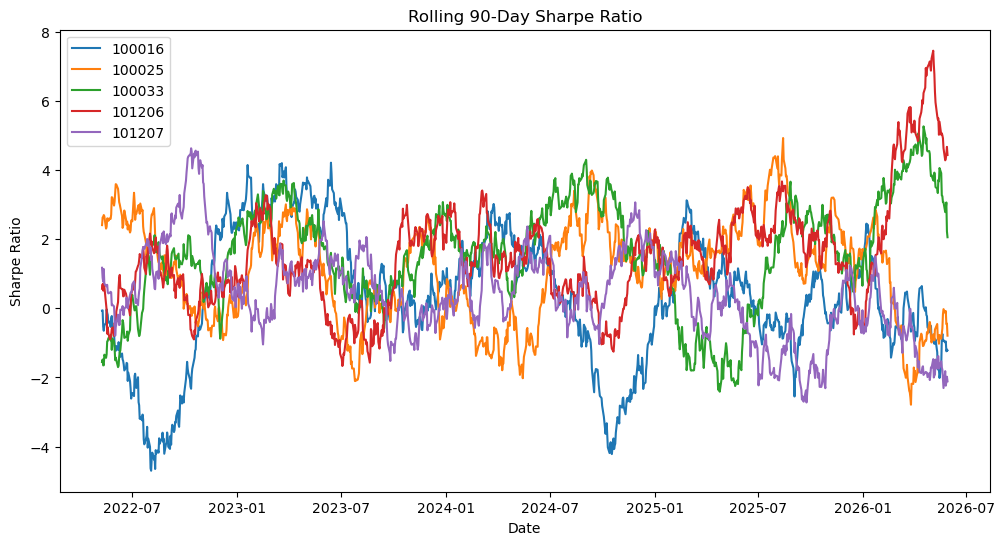

In [15]:
sample_funds = nav['amfi_code'].unique()[:5]

plt.figure(figsize=(12,6))

for fund in sample_funds:

    df = nav[nav['amfi_code']==fund].copy()

    rolling_sharpe = (
        df['daily_return']
        .rolling(90)
        .mean()
        /
        df['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df['date'],
        rolling_sharpe,
        label=str(fund)
    )

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.savefig(
    "../outputs/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

# Task 3: Cohort Analysis

In [18]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

first_txn = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
)

transactions['cohort_year'] = (
    transactions['investor_id']
    .map(first_txn.dt.year)
)

cohort_analysis = (
    transactions
    .groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum')
    )
    .reset_index()
)

fund_pref = pd.crosstab(
    transactions['cohort_year'],
    transactions['amfi_code']
)

cohort_analysis.to_csv(
    "../outputs/cohort_analysis.csv",
    index=False
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


# Task 4: SIP Continuity

In [33]:
sip = transactions[
    transactions['transaction_type'] == 'SIP'
].copy()

sip['transaction_date'] = pd.to_datetime(
    sip['transaction_date']
)

sip = sip.sort_values(
    ['investor_id', 'transaction_date']
)

sip['gap_days'] = (
    sip.groupby('investor_id')['transaction_date']
       .diff()
       .dt.days
)

sip_continuity = (
    sip.groupby('investor_id')
       .agg(
           sip_count=('transaction_date', 'count'),
           avg_gap_days=('gap_days', 'mean')
       )
       .reset_index()
)

sip_continuity = sip_continuity[
    sip_continuity['sip_count'] >= 6
]

sip_continuity['risk_flag'] = np.where(
    sip_continuity['avg_gap_days'] > 35,
    'At-Risk',
    'Healthy'
)

sip_continuity.head()

,investor_id,sip_count,avg_gap_days,risk_flag
3,INV000004,6,85.400000,At-Risk
7,INV000008,6,70.400000,At-Risk
9,INV000010,6,64.800000,At-Risk
10,INV000011,7,40.166667,At-Risk
11,INV000012,8,57.000000,At-Risk


In [35]:
sip_continuity.to_csv(
    "../outputs/sip_continuity.csv",
    index=False
)

# Task 5: Fund Recommendation Model

In [37]:
def recommend_funds(risk_level):

    subset = scheme_perf[
        scheme_perf['risk_grade']
        .str.lower()
        ==
        risk_level.lower()
    ]

    return (
        subset
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        [['scheme_name',
          'risk_grade',
          'sharpe_ratio']]
        .head(3)
    )

print(recommend_funds("Moderate"))

                                      scheme_name risk_grade  sharpe_ratio
5       HDFC Top 100 Fund - Regular Plan - Growth   Moderate          1.06
34  Mirae Asset Large Cap Fund - Regular - Growth   Moderate          1.06
11      ICICI Pru Bluechip Fund - Direct - Growth   Moderate          1.03


# Task 6: Sector HHI

In [39]:
sector_weights = (
    holdings
    .groupby(['amfi_code','sector'])
    ['weight_pct']
    .sum()
    .reset_index()
)

sector_weights['weight_decimal'] = (
    sector_weights['weight_pct'] / 100
)

hhi = (
    sector_weights
    .groupby('amfi_code')
    ['weight_decimal']
    .apply(lambda x: (x**2).sum())
    .reset_index(name='HHI')
)

hhi.to_csv(
    "../outputs/sector_hhi.csv",
    index=False
)

hhi.sort_values(
    'HHI',
    ascending=False
).head()

,amfi_code,HHI
11,119092,0.296769
30,148569,0.254992
27,125498,0.253155
6,102887,0.251383
32,149323,0.241077


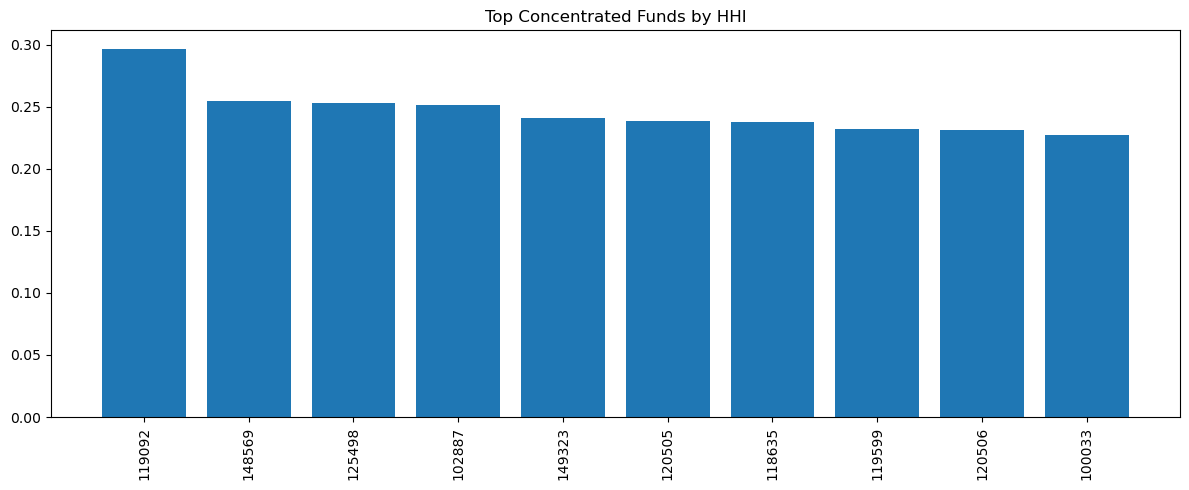

In [29]:
# Chart
plt.figure(figsize=(12,5))

top10 = hhi.sort_values(
    'HHI',
    ascending=False
).head(10)

plt.bar(
    top10['amfi_code'].astype(str),
    top10['HHI']
)

plt.xticks(rotation=90)
plt.title("Top Concentrated Funds by HHI")

plt.tight_layout()

plt.savefig(
    "../outputs/sector_hhi_chart.png"
)

plt.show()

# Advanced Analytics Summary

## Key Insights

1. Historical VaR and CVaR analysis identified funds with varying levels of downside risk. Fund 101207 showed one of the highest potential losses during adverse market conditions.

2. Rolling 90-Day Sharpe Ratio analysis demonstrated significant differences in risk-adjusted performance among the selected funds over time.

3. Investor cohort analysis revealed that the 2024 cohort contributed the highest total investment amount (~₹3.49 Billion), while the 2025 cohort had a slightly higher average investment amount.

4. SIP continuity analysis flagged several investors as **At-Risk** due to average SIP gaps greater than 35 days, indicating potential discontinuation of systematic investments.

5. Sector concentration analysis using the Herfindahl-Hirschman Index (HHI) showed that fund 119092 had the highest concentration score (HHI = 0.297), suggesting lower diversification compared to other funds.

## Conclusion

The analysis successfully evaluated mutual fund risk, investor behaviour, portfolio concentration, and fund suitability. These insights can support better investment decisions, risk monitoring, and personalized fund recommendations.